# PAMAP2 Human Activity Recognition (HAR) - Full Pipeline

## Overview
This notebook implements a complete end-to-end machine learning pipeline for Human Activity Recognition (HAR) using the PAMAP2 dataset. The pipeline includes:

- **Data Loading & Preprocessing**: Loading raw sensor data and defining activity labels
- **Data Cleaning**: Handling duplicates, missing values, and outliers
- **Signal Processing**: Filtering gravity and noise from IMU sensor data
- **Feature Engineering**: Creating sliding windows and extracting statistical features
- **Model Training**: Training and comparing multiple classifiers (LR, SVM, Random Forest)
- **Evaluation**: Leave-One-Group-Out (LOGO) cross-validation for subject-independent evaluation

## Dataset: PAMAP2
The PAMAP2 (Physical Activity Monitoring) dataset contains data from multiple subjects performing different activities using three IMU sensors (hand, chest, ankle). Each sensor records:
- 3-axis accelerometer data (16-bit and 6-bit resolution)
- Gyroscope data (3-axis rotation rates)
- Magnetometer data (magnetic field)
- Temperature readings

## Key Pipeline Steps
1. Parse raw sensor files and assign activity labels
2. Clean sensor data (remove duplicates, handle missing values, detect outliers)
3. Filter noise and gravity component from acceleration using low-pass butterworth filter
4. Create overlapping sliding windows (window size: 200 samples ≈ 2 sec @ 100Hz)
5. Extract 50+ statistical and spectral features per sensor per window
6. Train classifiers using Leave-One-Group-Out cross-validation (subject-independent)

In [1]:
# ==================== REQUIRED LIBRARIES ====================

# Data manipulation and analysis
import pandas as pd
from pathlib import Path

# Visualization
import seaborn as sns
from matplotlib import pyplot as plt

# Scientific computing (imported later in pipeline but listed here for completeness)
import numpy as np  # For numerical operations
from scipy.signal import butter, filtfilt  # For signal filtering
from scipy import stats  # For statistical computations

# Dimensionality reduction
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE # For 2D visualization

# Models 
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

## Step 1: Define Sensor Columns & Activity Mapping

The PAMAP2 raw data files (.dat) contain sensor readings in a specific order. We define the exact column names and activity labels here.

In [2]:
# Column names corresponding to PAMAP2 dataset structure
# Each row in the .dat files has this exact order of values

columns = [
    # Timestamp - marks when the measurement was taken
    'timestamp',

    # Activity indicator - identifies what activity was performed
    'activity_id',

    # Heart rate measurement (note: will be removed later due to high missing rate)
    'heart_rate',

    # ===== HAND SENSOR (right wrist) =====
    'imu_hand_temperature',
    # Accelerometer 16-bit (higher resolution, captures all movements)
    'imu_hand_accel_16_x',
    'imu_hand_accel_16_y',
    'imu_hand_accel_16_z',
    # Accelerometer 6-bit (low resolution variant)
    'imu_hand_accel_6_x',
    'imu_hand_accel_6_y',
    'imu_hand_accel_6_z',
    # Gyroscope (angular velocity / rotation rates)
    'imu_hand_gyro_x',
    'imu_hand_gyro_y',
    'imu_hand_gyro_z',
    # Magnetometer (magnetic field components)
    'imu_hand_magnet_x',
    'imu_hand_magnet_y',
    'imu_hand_magnet_z',
    # Orientation (quaternion representation of 3D orientation)
    'imu_hand_orientation_1',
    'imu_hand_orientation_2',
    'imu_hand_orientation_3',
    'imu_hand_orientation_4',

    # ===== CHEST SENSOR =====
    'imu_chest_temperature',
    'imu_chest_accel_16_x',
    'imu_chest_accel_16_y',
    'imu_chest_accel_16_z',
    'imu_chest_accel_6_x',
    'imu_chest_accel_6_y',
    'imu_chest_accel_6_z',
    'imu_chest_gyro_x',
    'imu_chest_gyro_y',
    'imu_chest_gyro_z',
    'imu_chest_magnet_x',
    'imu_chest_magnet_y',
    'imu_chest_magnet_z',
    'imu_chest_orientation_1',
    'imu_chest_orientation_2',
    'imu_chest_orientation_3',
    'imu_chest_orientation_4',

    # ===== ANKLE SENSOR =====
    'imu_ankle_temperature',
    'imu_ankle_accel_16_x',
    'imu_ankle_accel_16_y',
    'imu_ankle_accel_16_z',
    'imu_ankle_accel_6_x',
    'imu_ankle_accel_6_y',
    'imu_ankle_accel_6_z',
    'imu_ankle_gyro_x',
    'imu_ankle_gyro_y',
    'imu_ankle_gyro_z',
    'imu_ankle_magnet_x',
    'imu_ankle_magnet_y',
    'imu_ankle_magnet_z',
    'imu_ankle_orientation_1',
    'imu_ankle_orientation_2',
    'imu_ankle_orientation_3',
    'imu_ankle_orientation_4',
]

# ==================== ACTIVITY MAPPING ====================
# Maps numeric activity IDs to human-readable labels
# Used throughout the pipeline for labeling and visualization
activities = {
    0: 'Other',  # Miscellaneous/unlabeled activity
    1: 'Lying',
    2: 'Sitting',
    3: 'Standing',
    4: 'Walking',
    5: 'Running',
    6: 'Cycling',
    7: 'Nordic Walking',
    9: 'Watching TV',
    10: 'Computer Work',
    11: 'Car Driving',
    12: 'Ascending Stairs',
    13: 'Descending Stairs',
    16: 'Vacuum Cleaning',
    17: 'Ironing',
    18: 'Folding Laundry',
    19: 'House Cleaning',
    20: 'Playing Soccer',
    24: 'Rope Jumping'
}

In [3]:
def load_pamap2_dataset(dataset_dir='../data/PAMAP2_Dataset'):
    """
    Load PAMAP2 dataset files from both Protocol and Optional folders.
    
    Parameters:
    -----------
    dataset_dir : str
        Path to the PAMAP2_Dataset directory
        
    Returns:
    --------
    protocol_df : pd.DataFrame
        DataFrame with protocol recordings (structured activities)
    optional_df : pd.DataFrame
        DataFrame with optional recordings (ad-hoc activities)
    combined_df : pd.DataFrame
        DataFrame combining both protocol and optional recordings
    """
    
    # Create Path object for easy file globbing
    dataset_path = Path(dataset_dir)
    
    # Find all subject files (.dat format) in both folders
    protocol_files = sorted(dataset_path.glob('Protocol/subject*.dat'))
    optional_files = sorted(dataset_path.glob('Optional/subject*.dat'))
    
    # Initialize lists to store DataFrames before concatenation
    dfs_protocol = []
    dfs_optional = []
    
    # ===== LOAD PROTOCOL FILES =====
    # Each file contains data from one subject performing structured activities
    for file in protocol_files:
        # Read space-separated values (no header in raw files)
        df = pd.read_csv(file, sep=' ', header=None)
        
        # Assign column names based on our predefined column list
        # Note: columns are assigned in order, and extra columns are ignored
        df.columns = columns[:df.shape[1]]
        
        # Extract subject ID from filename (e.g., "subject101.dat" → 101)
        df['subject_id'] = int(file.stem.replace('subject', ''))
        
        dfs_protocol.append(df)
    
    # ===== LOAD OPTIONAL FILES =====
    # Similar process for optional recordings
    for file in optional_files:
        df = pd.read_csv(file, sep=' ', header=None)
        df.columns = columns[:df.shape[1]]
        df['subject_id'] = int(file.stem.replace('subject', ''))
        dfs_optional.append(df)
    
    # ===== CONCATENATE DATAFRAMES =====
    # Combine all files of each type, resetting index
    protocol_df = pd.concat(dfs_protocol, ignore_index=True)
    optional_df = pd.concat(dfs_optional, ignore_index=True)
    combined_df = pd.concat(dfs_protocol + dfs_optional, ignore_index=True)
    
    # ===== MAP ACTIVITY IDS TO NAMES =====
    # Add human-readable activity labels to all DataFrames
    for df in [protocol_df, optional_df, combined_df]:
        df['activity_name'] = df['activity_id'].map(activities)
    
    return protocol_df, optional_df, combined_df

## Step 2: Load PAMAP2 Dataset

The dataset is organized into two categories:
- **Protocol**: Predefined activities performed following a specific protocol
- **Optional**: Additional ad-hoc recordings by subjects

We load both and can work with either protocol, optional, or combined data.

In [4]:
# Load combined dataset (protocol + optional recordings)
# We only use the combined dataframe for this analysis
_, _, df = load_pamap2_dataset()

# Filter out 'Other' activity (activity_id=0) to focus on well-defined activities
# This improves model training by removing ambiguous/miscellaneous samples
df = df[df['activity_id'] != 0].copy()

# Remove 'Other' from the activity mapping dictionary as well
activities.pop(0)

# Note: Uncomment below if you want to exclude lower-resolution accelerometer data
df = df.drop(columns=[col for col in df.columns if '_accel_6_' in col])
df = df.drop(columns=['imu_hand_magnet_x' ,'imu_hand_magnet_y', 'imu_hand_magnet_z', 'imu_chest_magnet_x', 'imu_chest_magnet_y', 'imu_chest_magnet_z', 'imu_ankle_magnet_x', 'imu_ankle_magnet_y', 'imu_ankle_magnet_z'])

'Other'

### Load and Initialize Data
We load the combined dataset (both protocol and optional recordings) and filter out the 'Other' activity class to focus on well-defined activities.

## Step 3: Data Cleaning

### 3.1: Remove Duplicates
Eliminate duplicate records (same timestamp, subject, and activity) which can bias the model.

In [5]:
# Show dataset size before handling duplicates
print('Shape before removing duplicates: ', df.shape)

# Remove duplicate rows based on timestamp, subject_id, and activity_id
# This keeps the first occurrence and removes subsequent duplicates
df = df.drop_duplicates(subset=['timestamp', 'subject_id', 'activity_id'])

# Show dataset size after cleaning
print('Shape after removing duplicates: ', df.shape)

Shape before removing duplicates:  (2724953, 56)
Shape after removing duplicates:  (2724953, 56)


No duplicated lines

### 3.2: Analyze Missing Values
Check for missing data in sensor readings. High missingness in some sensors may require removal or imputation.

In [ ]:
# Count missing values (NaN) for each column
# Shows the number of missing samples for each sensor/metric
missing_counts = df.isna().sum()
print("Missing values per column:")
print(missing_counts[missing_counts > 0])  # Only show columns with missing values

timestamp                        0
activity_id                      0
heart_rate                 2476126
imu_hand_temperature         11868
imu_hand_accel_16_x          11868
imu_hand_accel_16_y          11868
imu_hand_accel_16_z          11868
imu_hand_accel_6_x           11868
imu_hand_accel_6_y           11868
imu_hand_accel_6_z           11868
imu_hand_gyro_x              11868
imu_hand_gyro_y              11868
imu_hand_gyro_z              11868
imu_hand_magnet_x            11868
imu_hand_magnet_y            11868
imu_hand_magnet_z            11868
imu_hand_orientation_1       11868
imu_hand_orientation_2       11868
imu_hand_orientation_3       11868
imu_hand_orientation_4       11868
imu_chest_temperature         3058
imu_chest_accel_16_x          3058
imu_chest_accel_16_y          3058
imu_chest_accel_16_z          3058
imu_chest_accel_6_x           3058
imu_chest_accel_6_y           3058
imu_chest_accel_6_z           3058
imu_chest_gyro_x              3058
imu_chest_gyro_y    

### Missing Values Analysis Summary
- **Heart rate**: ~90.86% missing (2,476,126 / 2,724,953) ← Remove this column
- **Hand sensors**: ~0.4% missing
- **Chest sensors**: ~0.11% missing  
- **Ankle sensors**: ~0.36% missing

The heart_rate column has excessive missingness (~91%) and will be dropped. IMU sensors have minimal missingness which will be handled via interpolation.

In [6]:
missing_pct_by_subject = df.groupby('subject_id').apply(lambda g: g.isna().mean() * 100)
print(missing_pct_by_subject.round(2))

            timestamp  activity_id  heart_rate  imu_hand_temperature  \
subject_id                                                             
101               0.0          0.0       90.86                  0.30   
102               0.0          0.0       90.86                  0.93   
103               0.0          0.0       90.86                  0.28   
104               0.0          0.0       90.86                  0.93   
105               0.0          0.0       90.87                  0.35   
106               0.0          0.0       90.87                  0.25   
107               0.0          0.0       90.87                  0.60   
108               0.0          0.0       90.89                  0.32   
109               0.0          0.0       90.88                  0.19   

            imu_hand_accel_16_x  imu_hand_accel_16_y  imu_hand_accel_16_z  \
subject_id                                                                  
101                        0.30                 0.30 

In [8]:
# Drop heart_rate column due to excessive missing values (~91%)
# This sensor has too little data to be reliable for training
df = df.drop(columns=['heart_rate'])

In [9]:
# Get all sensor columns (start with 'imu_' prefix)
sensor_cols = [col for col in df.columns if 'imu_' in col]

# Sort data by subject and timestamp to ensure proper interpolation order
df = df.sort_values(by=['subject_id', 'timestamp'])

# Linear interpolation for missing values WITHIN each subject
# This preserves temporal coherence and respects subject boundaries
# (doesn't interpolate across subjects)
df[sensor_cols] = (
    df.groupby('subject_id')[sensor_cols].transform(lambda x: x.interpolate(method='linear'))
)

### 3.3: Handle Missing Values via Interpolation
For remaining missing values in IMU sensors, use linear interpolation within each subject to preserve temporal continuity.

In [10]:
# ===== VERIFICATION: Check that all missing values are handled =====
print("Remaining missing values after interpolation:")
remaining_missing = df.isna().sum()
print(f"Total NaN values: {remaining_missing.sum()}")

print(f"\nDataset shape: {df.shape}")
print(f"Total rows: {df.shape[0]}, Total columns: {df.shape[1]}")

Remaining missing values after interpolation:
Total NaN values: 0

Dataset shape: (2724953, 56)
Total rows: 2724953, Total columns: 56


### 3.4: Outlier Detection Using IQR Method
Detect outliers for each sensor within each activity class using the Interquartile Range (IQR) method.
This helps identify erratic sensor readings while preserving extreme but valid values tied to specific activities.

**IQR Method**: 
- Lower bound = Q1 - 3×IQR
- Upper bound = Q3 + 3×IQR
- Values outside these bounds are flagged as potential outliers

In [ ]:
# Example boxplot visualization (currently commented out for efficiency)
# Uncomment to visualize sensor distributions and outliers
# hand_cols = [col for col in df.columns if 'imu_hand' in col]
#
# plt.figure(figsize=(15,6))
# sns.boxplot(data=df[hand_cols])
# plt.xticks(rotation=45)
# plt.title('Boxplots - Hand Sensors (Raw Data)')
# plt.show()

In [11]:
# ===== OUTLIER DETECTION (Activity-based IQR) =====
# For each sensor and each activity, calculate IQR bounds
# This assumes different activities have different expected sensor ranges

print("Outlier Detection Results (using 3×IQR threshold):")
print("-" * 50)

for col in sensor_cols:
    # Calculate Q1 (25th percentile) grouped by activity
    Q1 = df.groupby('activity_id')[col].transform('quantile', 0.25)
    
    # Calculate Q3 (75th percentile) grouped by activity
    Q3 = df.groupby('activity_id')[col].transform('quantile', 0.75)
    
    # Interquartile range
    IQR = Q3 - Q1
    
    # Bounds (using 3× IQR for stricter thresholding)
    borne_inf = Q1 - 3 * IQR  # Lower bound
    borne_sup = Q3 + 3 * IQR  # Upper bound

    # Identify outliers as values outside bounds
    outliers_mask = (df[col] < borne_inf) | (df[col] > borne_sup)
    
    # Report number of outliers found
    n_outliers = outliers_mask.sum()
    if n_outliers > 0:
        pct = 100 * n_outliers / len(df)
        print(f"{col:30} : {n_outliers:6} outliers ({pct:.2f}%)")

Outlier Detection Results (using 3×IQR threshold):
--------------------------------------------------
imu_hand_temperature           :     16 outliers (0.00%)
imu_hand_accel_16_x            :  44087 outliers (1.62%)
imu_hand_accel_16_y            :  19904 outliers (0.73%)
imu_hand_accel_16_z            :  26092 outliers (0.96%)
imu_hand_accel_6_x             :  42942 outliers (1.58%)
imu_hand_accel_6_y             :  17615 outliers (0.65%)
imu_hand_accel_6_z             :  27730 outliers (1.02%)
imu_hand_gyro_x                : 158430 outliers (5.81%)
imu_hand_gyro_y                : 121614 outliers (4.46%)
imu_hand_gyro_z                : 133702 outliers (4.91%)
imu_hand_magnet_x              :  30058 outliers (1.10%)
imu_hand_magnet_y              :   7700 outliers (0.28%)
imu_hand_magnet_z              :  83311 outliers (3.06%)
imu_hand_orientation_2         :   1778 outliers (0.07%)
imu_hand_orientation_3         :   9461 outliers (0.35%)
imu_chest_temperature          :     58 out

Decision: outliers are NOT removed at this stage. Given that bounds were computed per activity (preserving activity-specific dynamics), most flagged values likely represent genuine physiological signal rather than sensor noise. The upcoming Butterworth low-pass filtering step will further attenuate high-frequency noise before feature extraction.

## Step 4: Data Exploration & Visualization

Explore the cleaned dataset to understand activity distributions and sensor patterns.

Dataset Statistical Summary:
          timestamp   activity_id  imu_hand_temperature  imu_hand_accel_16_x  \
count  2.724953e+06  2.724953e+06          2.724953e+06         2.724953e+06   
mean   1.529966e+03  9.705309e+00          3.281591e+01        -3.763532e+00   
std    1.039252e+03  6.277255e+00          1.900176e+00         6.315877e+00   
min    3.120000e+01  1.000000e+00          2.487500e+01        -1.546090e+02   
25%    6.523200e+02  4.000000e+00          3.181250e+01        -8.377910e+00   
50%    1.302070e+03  1.000000e+01          3.318750e+01        -3.346900e+00   
75%    2.382700e+03  1.600000e+01          3.418750e+01         3.246710e-01   
max    4.245680e+03  2.400000e+01          3.550000e+01         1.060340e+02   

       imu_hand_accel_16_y  imu_hand_accel_16_z  imu_hand_accel_6_x  \
count         2.724953e+06         2.724953e+06        2.724953e+06   
mean          3.637916e+00         3.976831e+00       -3.687644e+00   
std           6.588388e+00         4.

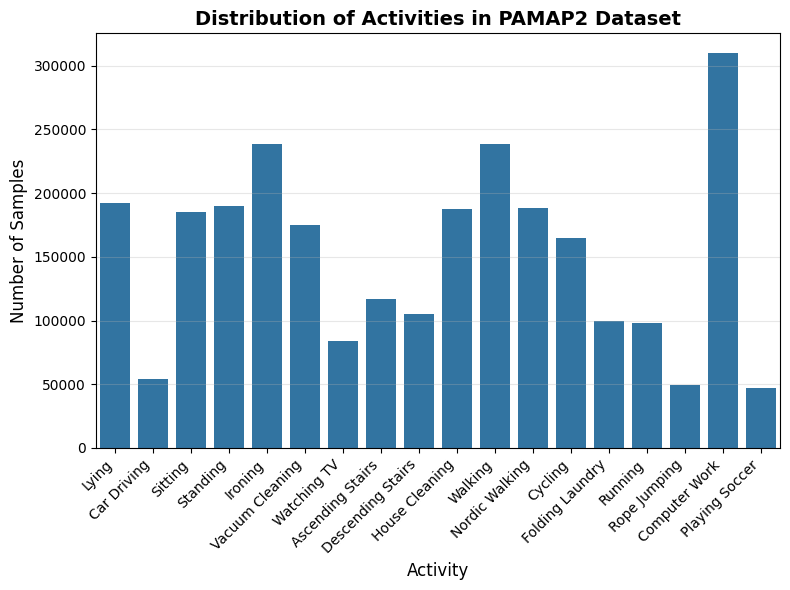

In [12]:
# ===== DATASET SUMMARY STATISTICS =====
print("Dataset Statistical Summary:")
print(df.describe())

print("\n" + "="*60)

# ===== ACTIVITY DISTRIBUTION =====
# Visualize class imbalance - important for understanding dataset composition
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='activity_name')
plt.xlabel('Activity', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.title('Distribution of Activities in PAMAP2 Dataset', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
def plot_session(sensor):
    """
    Plot average sensor signal patterns for each activity.
    
    Shows how a specific sensor varies over time for each activity class.
    Useful for understanding characteristic patterns and inter-subject variability.
    
    Parameters:
    -----------
    sensor : str
        Column name of the sensor to plot (e.g., 'imu_ankle_accel_16_z')
    """
    plt.figure(figsize=(12, 8))

    # Iterate through all activities (20 activities total)
    for i, activity_id in enumerate(activities):
        
        # Get all samples for this activity
        all_recordings = df[df['activity_id'] == activity_id].copy()
        
        # Sort by timestamp to maintain temporal order
        all_recordings = all_recordings.sort_values('timestamp')
        
        # Create relative index (0, 1, 2, ...) within each subject
        # This aligns recordings of different lengths
        all_recordings['relative_idx'] = all_recordings.groupby('subject_id').cumcount()

        # Calculate mean signal value at each relative time point
        activity_avg = all_recordings.groupby('relative_idx')[sensor].mean()
        
        # Calculate standard deviation (for confidence intervals)
        activity_std = all_recordings.groupby('relative_idx')[sensor].std()

        # Create DataFrame with mean, std, and bounds
        result_df = pd.DataFrame({
            'relative_idx': activity_avg.index, 
            'avg_value': activity_avg, 
            'std_value': activity_std
        })

        # Calculate confidence interval bounds (mean ± std)
        result_df['upper'] = result_df['avg_value'] + result_df['std_value']
        result_df['lower'] = result_df['avg_value'] - result_df['std_value']

        # Create subplot for this activity (4 rows × 5 cols = 20 subplots)
        plt.subplot(4, 5, i + 1)
        
        # Plot mean signal
        plt.plot(result_df['relative_idx'], result_df['avg_value'], 
                color='blue', linewidth=2)
        
        # Add shaded confidence interval
        plt.fill_between(result_df['relative_idx'], 
                        result_df['lower'], 
                        result_df['upper'], 
                        alpha=0.2, color='blue')

        # Format subplot
        plt.xlabel('Relative Sample Index')
        plt.ylabel(f'{sensor}')
        plt.title(f"{activities[activity_id]}")
        plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

### Sensor Signal Patterns by Activity
Plot average sensor signals for each activity to visualize characteristic patterns and variability.

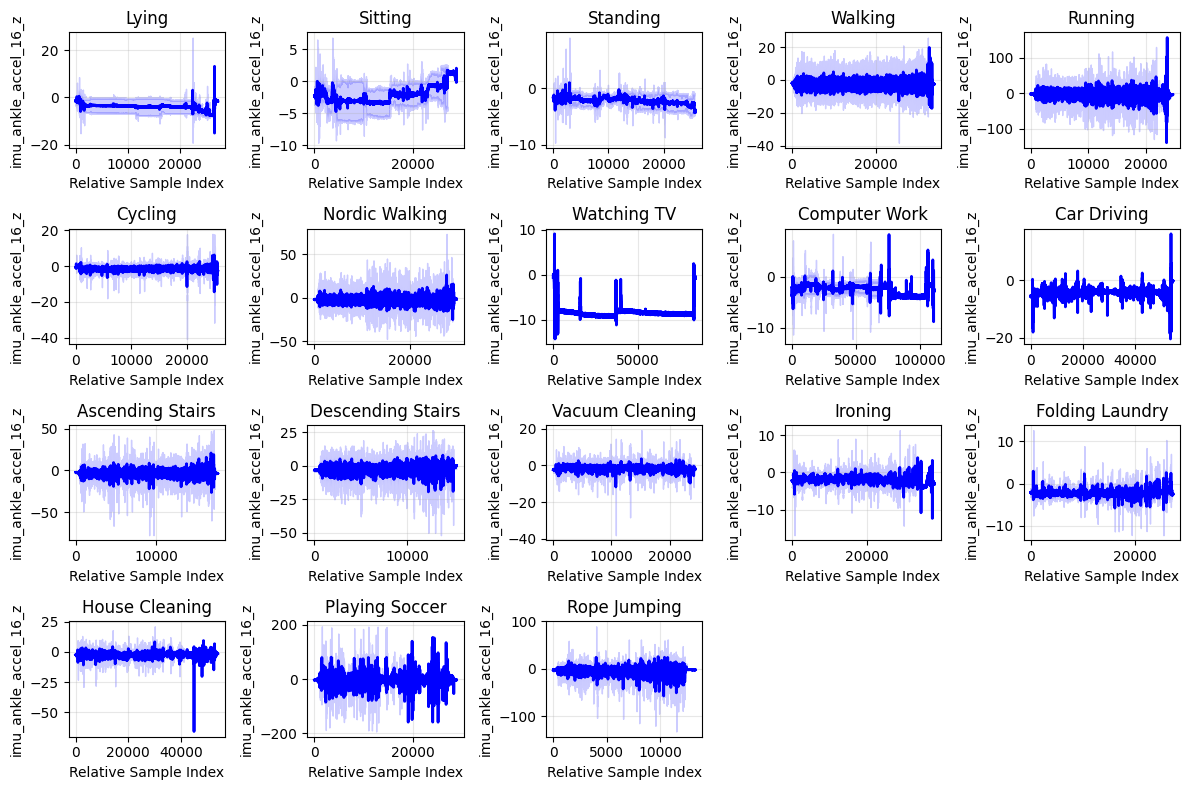

In [14]:
plot_session('imu_ankle_accel_16_z')

In [15]:
# ===== COMPUTE 3D ACCELERATION MAGNITUDE =====
# Magnitude = sqrt(x² + y² + z²)
# This represents the total acceleration in all directions
# Useful for activities like running/walking where overall motion intensity matters

# Hand sensor magnitude (16-bit accelerometer)
df['magnitude_hand_16'] = np.sqrt(
    df['imu_hand_accel_16_x']**2 + 
    df['imu_hand_accel_16_y']**2 + 
    df['imu_hand_accel_16_z']**2
)

# Chest sensor magnitude (16-bit accelerometer)
df['magnitude_chest_16'] = np.sqrt(
    df['imu_chest_accel_16_x']**2 +
    df['imu_chest_accel_16_y']**2 +
    df['imu_chest_accel_16_z']**2
)

# Ankle sensor magnitude (16-bit accelerometer)
df['magnitude_ankle_16'] = np.sqrt(
    df['imu_ankle_accel_16_x']**2 +
    df['imu_ankle_accel_16_y']**2 +
    df['imu_ankle_accel_16_z']**2
)

## Step 5: Signal Processing & Feature Engineering

### 5.1: Compute Acceleration Magnitude
Calculate the 3D magnitude (Euclidean norm) of acceleration vectors for each sensor position.
This reduces 3-axis acceleration data to a single representative value.

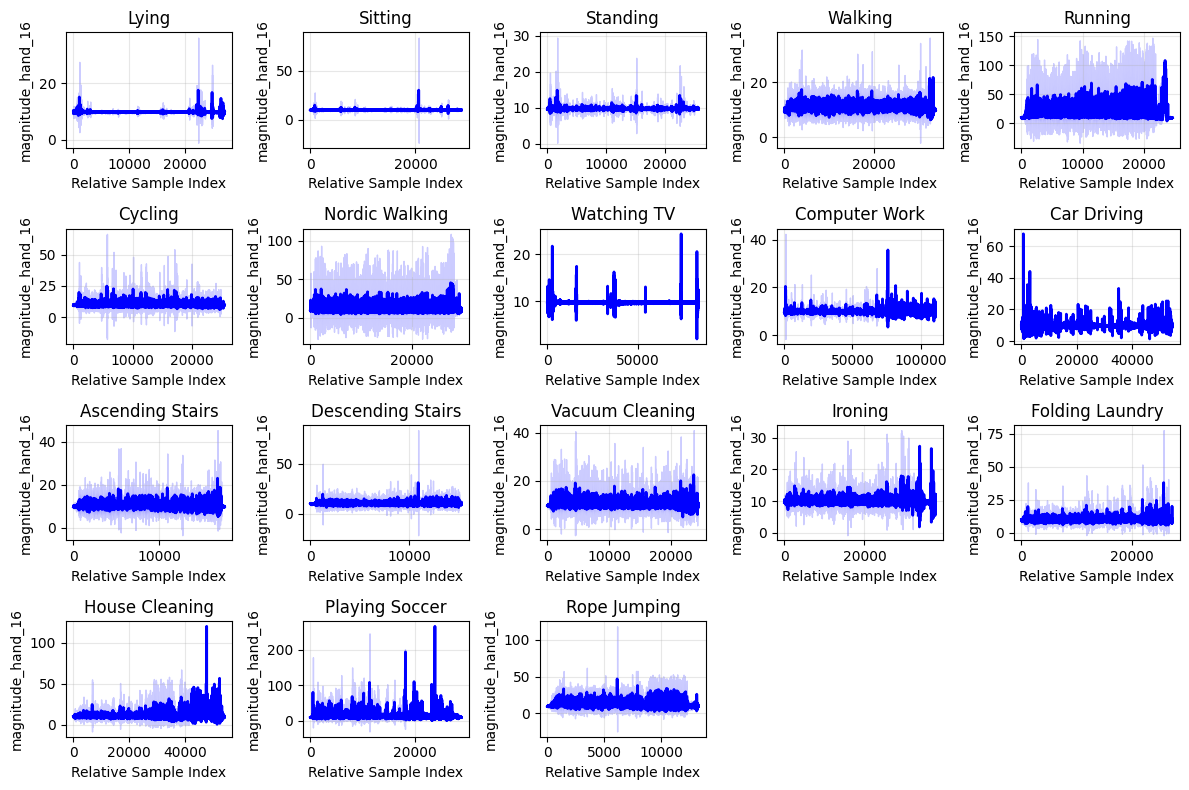

In [16]:
plot_session('magnitude_hand_16')

### 5.2: Filter Gravity Component from Acceleration

**Problem**: Accelerometers measure total acceleration = body motion + gravity (≈9.81 m/s² when still)

**Solution**: Use cascaded butterworth low-pass filters:
1. **High cutoff (20 Hz)**: Remove high-frequency noise → clean signal
2. **Low cutoff (0.3 Hz)**: Estimate gravity component (slowly varying)
3. **Subtract gravity from clean signal** → obtain body motion only

This preprocessing improves activity recognition by removing irrelevant DC offset and isolating true motion signals.

In [17]:
# ===== BUTTERWORTH LOW-PASS FILTER FUNCTION =====
def butter_lowpass_filter(data, cutoff, fs, order=4):
    """
    Apply a Butterworth low-pass filter to data.
    
    Parameters:
    -----------
    data : array-like
        Input signal to filter
    cutoff : float
        Cutoff frequency (Hz)
    fs : float
        Sampling frequency (Hz)
    order : int
        Filter order (default: 4). Higher = steeper roll-off
        
    Returns:
    --------
    filtered : ndarray
        Filtered signal (zero-phase using filtfilt)
    """
    # Normalize cutoff frequency to Nyquist frequency (fs/2)
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    
    # Design filter coefficients
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    
    # Apply filter (filtfilt applies forward-backward for zero phase delay)
    return filtfilt(b, a, data)

# ===== FILTER PARAMETERS =====
fs = 100                # Sampling rate: 100 Hz (PAMAP2 specification)
cutoff_noise = 20.0     # High-pass threshold: remove frequencies above 20 Hz
cutoff_gravity = 0.3    # Low-pass threshold: capture slow gravity component (≈0.1-0.5 Hz)

# ===== FILTER EACH SENSOR AXIS =====
# Apply gravity separation to all three sensor positions (hand, chest, ankle)
for pos in ['hand', 'ankle', 'chest']:
    for axis in ['x', 'y', 'z']:
        col = f'imu_{pos}_accel_16_{axis}'
        
        # Get raw acceleration data
        raw = df[col].values
        
        # Step 1: Remove high-frequency noise (cutoff: 20 Hz)
        # This keeps frequencies below 20 Hz including body motion and gravity
        clean = butter_lowpass_filter(raw, cutoff_noise, fs)
        
        # Step 2: Estimate gravity component (cutoff: 0.3 Hz)
        # This captures only very slow acceleration (gravity + slow tilts)
        gravity = butter_lowpass_filter(clean, cutoff_gravity, fs)

        # Step 3: Compute body acceleration (motion only)
        # body = total_acceleration - gravity
        body = clean - gravity

        # Store filtered body acceleration
        df[f'{col}_filtered'] = body

# ===== COMPUTE MAGNITUDE OF FILTERED ACCELERATION =====
# Now compute magnitude using gravity-removed data
for pos in ['hand', 'chest', 'ankle']:
    df[f'magnitude_{pos}_filtered'] = np.sqrt(
        df[f'imu_{pos}_accel_16_x_filtered']**2 +
        df[f'imu_{pos}_accel_16_y_filtered']**2 +
        df[f'imu_{pos}_accel_16_z_filtered']**2
    )

### Visualization: Raw vs Filtered Signal
Compare raw acceleration magnitude with filtered (gravity-removed) version to visualize the impact of preprocessing.

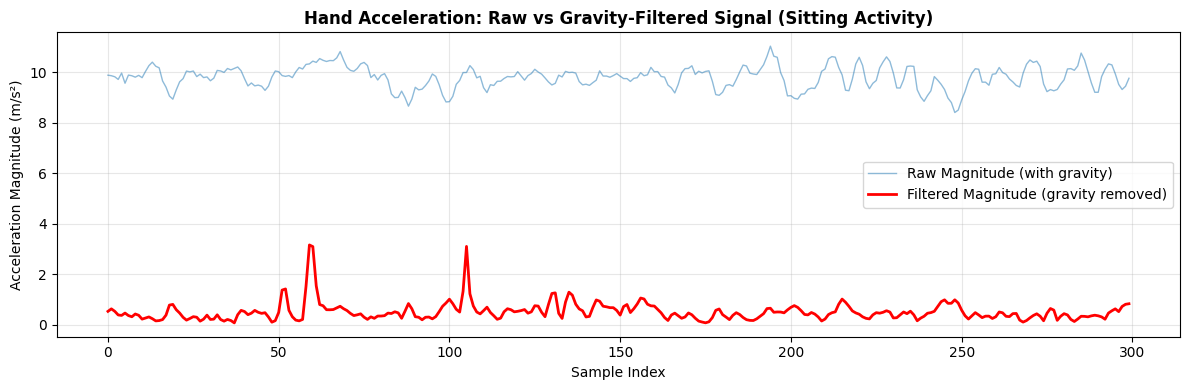

In [18]:
# Select a sample from "Sitting" activity for demonstration
df_sample = df[df['activity_name'] == 'Sitting'].head(300)

# Create comparison plot
plt.figure(figsize=(12, 4))

# Plot raw magnitude (includes gravity)
plt.plot(df_sample['magnitude_hand_16'].values, 
         label='Raw Magnitude (with gravity)', 
         alpha=0.5, linewidth=1)

# Plot filtered magnitude (gravity removed)
plt.plot(df_sample['magnitude_hand_filtered'].values, 
         label='Filtered Magnitude (gravity removed)', 
         linewidth=2, color='red')

plt.title('Hand Acceleration: Raw vs Gravity-Filtered Signal (Sitting Activity)', 
          fontsize=12, fontweight='bold')
plt.xlabel('Sample Index')
plt.ylabel('Acceleration Magnitude (m/s²)')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
df.head()

,timestamp,activity_id,imu_hand_temperature,imu_hand_accel_16_x,imu_hand_accel_16_y,imu_hand_accel_16_z,imu_hand_accel_6_x,imu_hand_accel_6_y,imu_hand_accel_6_z,imu_hand_gyro_x,...,imu_hand_accel_16_z_filtered,imu_ankle_accel_16_x_filtered,imu_ankle_accel_16_y_filtered,imu_ankle_accel_16_z_filtered,imu_chest_accel_16_x_filtered,imu_chest_accel_16_y_filtered,imu_chest_accel_16_z_filtered,magnitude_hand_filtered,magnitude_chest_filtered,magnitude_ankle_filtered
2928,37.66,1,30.375,2.21530,8.27915,5.58753,2.24689,8.55387,5.77143,-0.004750,...,-0.508192,-0.010406,0.013001,0.014605,-0.152147,0.010958,0.044639,0.579830,0.158939,0.022150
2929,37.67,1,30.375,2.29196,7.67288,5.74467,2.27373,8.14592,5.78739,-0.171710,...,-0.399361,-0.043690,-0.016244,-0.057842,-0.078862,0.043989,-0.030616,0.572561,0.095350,0.074286
2930,37.68,1,30.375,2.29090,7.14240,5.82342,2.26966,7.66268,5.78846,-0.238241,...,-0.273342,-0.052597,-0.029195,-0.070212,-0.022816,0.070328,-0.073086,0.855986,0.103962,0.092459
2931,37.69,1,30.375,2.21800,7.14365,5.89930,2.22177,7.25535,5.88000,-0.192912,...,-0.145778,-0.043219,-0.026986,-0.047339,0.007602,0.077467,-0.078860,0.952111,0.110806,0.069549
2932,37.70,1,30.375,2.30106,7.25857,6.09259,2.20720,7.24042,5.95555,-0.069961,...,-0.073198,-0.042259,-0.020211,-0.055898,0.016384,0.059872,-0.067647,0.848379,0.091811,0.072930


### 5.3: Compute Gyroscope Magnitude
Calculate 3D magnitude for gyroscope (angular velocity) data to capture overall rotation rates.

In [21]:
# ===== COMPUTE GYROSCOPE MAGNITUDE =====
# Gyroscope measures angular velocity (rotations per second)
# Magnitude = sqrt(Gx² + Gy² + Gz²)
# Useful for detecting rotation-based activities (e.g., turning while walking, head movements)

# Hand gyroscope magnitude (angular velocity)
df['acc_hand_gyro_mag'] = np.sqrt(
    df['imu_hand_gyro_x']**2 + 
    df['imu_hand_gyro_y']**2 + 
    df['imu_hand_gyro_z']**2
)

# Chest gyroscope magnitude
df['acc_chest_gyro_mag'] = np.sqrt(
    df['imu_chest_gyro_x']**2 + 
    df['imu_chest_gyro_y']**2 + 
    df['imu_chest_gyro_z']**2
)

# Ankle gyroscope magnitude
df['acc_ankle_gyro_mag'] = np.sqrt(
    df['imu_ankle_gyro_x']**2 + 
    df['imu_ankle_gyro_y']**2 + 
    df['imu_ankle_gyro_z']**2
)

# Note: Magnetometer (magnetic field) data can also be used but often contains noise
# and location-dependent interference. Currently commented out from feature set.
# Uncomment below to exclude lower-resolution 6-bit accelerometer data:
# df = df.drop(columns=[col for col in df.columns if '_accel_6_' in col])

## Step 6: Window Segmentation & Feature Extraction

### 6.1: Create Sliding Windows

The raw continuous time-series data must be segmented into fixed-size windows for feature extraction.

**Parameters**:
- **Window size**: 200 samples = 2 seconds @ 100 Hz sampling rate
- **Step size**: 100 samples = 50% overlap between windows
- **Grouping**: Windows are created separately for each (subject_id, activity_id) pair to ensure:
  - No windows span multiple activities
  - No windows span multiple subjects (important for subject-independent evaluation)

In [22]:
def sliding_window(df, window_size, step, group_cols=['subject_id', 'activity_id'], time_col='timestamp'):
    """
    Create sliding windows from time-series data.
    
    Windows are created within each group (subject + activity) to prevent:
    - Cross-activity contamination
    - Cross-subject contamination
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input dataframe with time-series data
    window_size : int
        Number of samples per window
    step : int
        Number of samples to slide window (stride)
        - step = window_size → non-overlapping windows
        - step < window_size → overlapping windows
    group_cols : list
        Columns to group by (create separate windows per group)
    time_col : str
        Column to sort by within each group
        
    Returns:
    --------
    pd.DataFrame
        Data with 'window_id' column added, ready for per-window feature extraction
    """
    
    # Sort data by group and timestamp
    sort_cols = group_cols + ([time_col] if time_col in df.columns else [])
    df = df.sort_values(sort_cols).reset_index(drop=True)

    windows = []  # List to store indices for each window
    window_id = 0

    # Create windows for each (subject, activity) group
    for _, group in df.groupby(group_cols, sort=False):
        # Get indices for this group's data
        idx = group.index.to_numpy()
        n = len(group)

        # Slide window across group data with specified step
        for start in range(0, n - window_size + 1, step):
            # Collect indices for this window
            windows.append(idx[start : start + window_size])
            window_id += 1

    # Handle case where no valid windows could be created
    if not windows:
        print("Warning: No valid windows created. Check window_size vs. data length.")
        return pd.DataFrame()

    # Concatenate all window indices
    all_idx = np.concatenate(windows)
    
    # Create result dataframe with only windowed data
    result = df.loc[all_idx].reset_index(drop=True)

    # Assign window IDs: each sample gets the ID of its window
    result["window_id"] = np.repeat(np.arange(len(windows)), window_size)

    return result


# ===== APPLY WINDOWING =====
WINDOW_SIZE = 200   # @ 100 Hz: 200 samples = 2.0 seconds
STEP = 100          # 50% overlap: next window starts at 100 samples

print("Creating sliding windows...")
print(f"  Window size: {WINDOW_SIZE} samples ({WINDOW_SIZE/100:.2f} seconds)")
print(f"  Step size:   {STEP} samples ({STEP/100:.2f} seconds)")
print(f"  Overlap:     {100 * (1 - STEP/WINDOW_SIZE):.0f}%\n")

df_windowed = sliding_window(df, window_size=WINDOW_SIZE, step=STEP)

Creating sliding windows...
  Window size: 200 samples (2.00 seconds)
  Step size:   100 samples (1.00 seconds)
  Overlap:     50%



In [23]:
# ===== WINDOWING VERIFICATION =====
# Show unique window IDs to verify windows were created
unique_windows = df_windowed['window_id'].unique()
print(f"Number of unique windows created: {len(unique_windows)}")
print(f"Window ID range: {unique_windows[0]} to {unique_windows[-1]}")

Number of unique windows created: 27083
Window ID range: 0 to 27082


In [23]:
df_windowed.head()

,timestamp,activity_id,imu_hand_temperature,imu_hand_accel_16_x,imu_hand_accel_16_y,imu_hand_accel_16_z,imu_hand_accel_6_x,imu_hand_accel_6_y,imu_hand_accel_6_z,imu_hand_gyro_x,...,imu_ankle_accel_16_z_filtered,magnitude_ankle_filtered,imu_chest_accel_16_x_filtered,imu_chest_accel_16_y_filtered,imu_chest_accel_16_z_filtered,magnitude_chest_filtered,acc_hand_gyro_mag,acc_chest_gyro_mag,acc_ankle_gyro_mag,window_id
0,37.66,1,30.375,2.21530,8.27915,5.58753,2.24689,8.55387,5.77143,-0.004750,...,0.014605,0.022150,-0.152147,0.010958,0.044639,0.158939,0.039483,0.066375,0.027921,0
1,37.67,1,30.375,2.29196,7.67288,5.74467,2.27373,8.14592,5.78739,-0.171710,...,-0.057842,0.074286,-0.078862,0.043989,-0.030616,0.095350,0.173852,0.067424,0.021749,0
2,37.68,1,30.375,2.29090,7.14240,5.82342,2.26966,7.66268,5.78846,-0.238241,...,-0.070212,0.092459,-0.022816,0.070328,-0.073086,0.103962,0.238506,0.060338,0.063439,0
3,37.69,1,30.375,2.21800,7.14365,5.89930,2.22177,7.25535,5.88000,-0.192912,...,-0.047339,0.069549,0.007602,0.077467,-0.078860,0.110806,0.194311,0.090952,0.046244,0
4,37.70,1,30.375,2.30106,7.25857,6.09259,2.20720,7.24042,5.95555,-0.069961,...,-0.055898,0.072930,0.016384,0.059872,-0.067647,0.091811,0.072467,0.041521,0.049304,0


In [24]:
# ===== WINDOWED DATASET STATISTICS =====
print("Windowed dataset statistics:")
print(f"  Total samples (rows): {df_windowed.shape[0]:,}")
print(f"  Unique windows:       {df_windowed['window_id'].nunique():,}")
print(f"  Total columns:        {df_windowed.shape[1]}")
print(f"  Samples per window:   {WINDOW_SIZE}")
print(f"  RAM used:             {df_windowed.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Windowed dataset statistics:
  Total samples (rows): 5,416,600
  Unique windows:       27,083
  Total columns:        75
  Samples per window:   200
  RAM used:             3.53 GB


In [25]:
df_windowed.columns

Index(['timestamp', 'activity_id', 'imu_hand_temperature',
       'imu_hand_accel_16_x', 'imu_hand_accel_16_y', 'imu_hand_accel_16_z',
       'imu_hand_accel_6_x', 'imu_hand_accel_6_y', 'imu_hand_accel_6_z',
       'imu_hand_gyro_x', 'imu_hand_gyro_y', 'imu_hand_gyro_z',
       'imu_hand_magnet_x', 'imu_hand_magnet_y', 'imu_hand_magnet_z',
       'imu_hand_orientation_1', 'imu_hand_orientation_2',
       'imu_hand_orientation_3', 'imu_hand_orientation_4',
       'imu_chest_temperature', 'imu_chest_accel_16_x', 'imu_chest_accel_16_y',
       'imu_chest_accel_16_z', 'imu_chest_accel_6_x', 'imu_chest_accel_6_y',
       'imu_chest_accel_6_z', 'imu_chest_gyro_x', 'imu_chest_gyro_y',
       'imu_chest_gyro_z', 'imu_chest_magnet_x', 'imu_chest_magnet_y',
       'imu_chest_magnet_z', 'imu_chest_orientation_1',
       'imu_chest_orientation_2', 'imu_chest_orientation_3',
       'imu_chest_orientation_4', 'imu_ankle_temperature',
       'imu_ankle_accel_16_x', 'imu_ankle_accel_16_y', 'imu_ankle_

### 6.2: Define Feature Columns

Select which sensor columns to use for feature extraction. These represent the raw signals from which statistical and spectral features will be computed.

In [ ]:
# ===== RENAME GYROSCOPE MAGNITUDE COLUMNS FOR CONSISTENCY =====
# Earlier we computed gyroscope magnitudes with 'acc_' prefix
# Rename to 'imu_' prefix to match other sensors
rename_map = {
    'acc_hand_gyro_mag':  'imu_hand_gyro_mag',
    'acc_chest_gyro_mag': 'imu_chest_gyro_mag',
    'acc_ankle_gyro_mag': 'imu_ankle_gyro_mag',
}
df_windowed = df_windowed.rename(columns=rename_map)

# ===== DEFINE FEATURE COLUMNS FOR EACH SENSOR POSITION =====
# These columns will be used to extract statistical features
# We focus on filtered acceleration + gyroscope data (good discriminative power)
# Include magnitude (scalar) and individual axes (x, y, z)

feature_cols = {
    'hand': [
        # Filtered acceleration (body motion, gravity removed) - 16-bit
        'imu_hand_accel_16_x_filtered', 
        'imu_hand_accel_16_y_filtered', 
        'imu_hand_accel_16_z_filtered', 
        'magnitude_hand_filtered',  # 3D magnitude
        # Gyroscope (angular velocity) - no filtering needed
        'imu_hand_gyro_x', 
        'imu_hand_gyro_y', 
        'imu_hand_gyro_z', 
        'imu_hand_gyro_mag',  # 3D magnitude
    ],
    'chest': [
        'imu_chest_accel_16_x_filtered', 
        'imu_chest_accel_16_y_filtered',
        'imu_chest_accel_16_z_filtered', 
        'magnitude_chest_filtered',
        'imu_chest_gyro_x', 
        'imu_chest_gyro_y',
        'imu_chest_gyro_z', 
        'imu_chest_gyro_mag',
    ],
    'ankle': [
        'imu_ankle_accel_16_x_filtered', 
        'imu_ankle_accel_16_y_filtered',
        'imu_ankle_accel_16_z_filtered', 
        'magnitude_ankle_filtered',
        'imu_ankle_gyro_x', 
        'imu_ankle_gyro_y',
        'imu_ankle_gyro_z', 
        'imu_ankle_gyro_mag',
    ],
}

In [28]:
df_windowed.columns

Index(['timestamp', 'activity_id', 'imu_hand_temperature',
       'imu_hand_accel_16_x', 'imu_hand_accel_16_y', 'imu_hand_accel_16_z',
       'imu_hand_accel_6_x', 'imu_hand_accel_6_y', 'imu_hand_accel_6_z',
       'imu_hand_gyro_x', 'imu_hand_gyro_y', 'imu_hand_gyro_z',
       'imu_hand_magnet_x', 'imu_hand_magnet_y', 'imu_hand_magnet_z',
       'imu_hand_orientation_1', 'imu_hand_orientation_2',
       'imu_hand_orientation_3', 'imu_hand_orientation_4',
       'imu_chest_temperature', 'imu_chest_accel_16_x', 'imu_chest_accel_16_y',
       'imu_chest_accel_16_z', 'imu_chest_accel_6_x', 'imu_chest_accel_6_y',
       'imu_chest_accel_6_z', 'imu_chest_gyro_x', 'imu_chest_gyro_y',
       'imu_chest_gyro_z', 'imu_chest_magnet_x', 'imu_chest_magnet_y',
       'imu_chest_magnet_z', 'imu_chest_orientation_1',
       'imu_chest_orientation_2', 'imu_chest_orientation_3',
       'imu_chest_orientation_4', 'imu_ankle_temperature',
       'imu_ankle_accel_16_x', 'imu_ankle_accel_16_y', 'imu_ankle_

In [ ]:
def extract_features(window: np.ndarray, feature_cols: list, verbose=False, i=None) -> dict:
    """
    Extract 50+ statistical and spectral features from a single time-series window.
    
    This function computes both time-domain and frequency-domain features that
    capture signal characteristics useful for activity recognition.
    
    Parameters:
    -----------
    window : np.ndarray
        2D array of shape (window_size, n_features) containing sensor data
    feature_cols : list
        Names of sensor columns (for feature naming)
    verbose : bool
        Print progress every 1000 windows
    i : int
        Current window index (for progress tracking)
        
    Returns:
    --------
    dict
        Dictionary with feature names as keys and computed values as values
    """
    
    if verbose and i is not None and i % 1000 == 0:
        print(f"[extract] Processing window {i}")

    feats = {}

    # Extract features for each sensor channel
    for i_col, col in enumerate(feature_cols):
        # Extract this sensor's values across all samples in the window
        x = window[:, i_col]

        # ===== TIME-DOMAIN FEATURES =====
        feats[f'{col}_mean']   = np.mean(x)                      # Average value
        feats[f'{col}_std']    = np.std(x)                       # Standard deviation (variability)
        feats[f'{col}_min']    = np.min(x)                       # Minimum value
        feats[f'{col}_max']    = np.max(x)                       # Maximum value
        feats[f'{col}_range']  = np.max(x) - np.min(x)           # Range (max - min)
        feats[f'{col}_median'] = np.median(x)                    # Median (50th percentile)
        feats[f'{col}_iqr']    = stats.iqr(x)                    # Interquartile range
        feats[f'{col}_rms']    = np.sqrt(np.mean(x**2))          # Root mean square (power)
        feats[f'{col}_energy'] = np.mean(x**2)                   # Signal energy
        feats[f'{col}_mad']    = np.mean(np.abs(x - np.mean(x))) # Mean absolute deviation
        feats[f'{col}_zc']     = np.sum(np.diff(np.sign(x)) != 0)# Zero crossings (oscillation count)

        # ===== FREQUENCY-DOMAIN FEATURES =====
        # Apply FFT to get frequency components
        fft_vals = np.abs(np.fft.rfft(x))  # Magnitude spectrum (real-valued)
        freqs = np.fft.rfftfreq(len(x), d=1/100)  # Frequency bins (100 Hz sampling)

        feats[f'{col}_fft_mean']      = np.mean(fft_vals)         # Average frequency component magnitude
        feats[f'{col}_fft_std']       = np.std(fft_vals)          # Variability in frequency domain
        feats[f'{col}_fft_energy']    = np.mean(fft_vals**2)      # Total frequency energy

        # Dominant (peak) frequency
        if len(fft_vals) > 1:
            # Skip DC component (index 0) and find dominant frequency
            peak_idx = np.argmax(fft_vals[1:]) + 1
            feats[f'{col}_dominant_freq'] = freqs[peak_idx]
        else:
            feats[f'{col}_dominant_freq'] = 0.0

        # Spectral entropy (measure of frequency distribution)
        # Normalized entropy: 0 = all power in one frequency, 1 = uniform distribution
        p = fft_vals / (np.sum(fft_vals) + 1e-10)  # Normalize to probability distribution
        feats[f'{col}_spectral_entropy'] = stats.entropy(p + 1e-10)

    return feats


def build_feature_matrix(df_windowed, feature_cols, meta_cols=None, verbose=True):
    """
    Build feature matrix by extracting features from all windows.
    
    Parameters:
    -----------
    df_windowed : pd.DataFrame
        Dataframe with 'window_id' column and sensor data
    feature_cols : list
        Column names to extract features from
    meta_cols : list
        Metadata columns to exclude from feature extraction
    verbose : bool
        Print progress information
        
    Returns:
    --------
    pd.DataFrame
        Feature matrix with one row per window
    """
    
    if meta_cols is None:
        meta_cols = ['subject_id', 'activity_id', 'timestamp', 'window_id']

    # Count windows and features
    n_windows  = df_windowed['window_id'].nunique()
    n_features = len(feature_cols)

    print("\n" + "="*60)
    print("FEATURE EXTRACTION CONFIGURATION")
    print("="*60)
    print(f"Number of windows    : {n_windows:,}")
    print(f"Features per window  : {n_features}")
    print(f"Est. features/window : ~{n_features * 11}  (time-domain + freq)")
    print(f"Verbose progress     : {'Yes' if verbose else 'No'}\n")

    # Reshape windowed data: (n_samples, n_features) → (n_windows, window_size, n_features)
    X_raw = df_windowed[feature_cols].to_numpy().reshape(n_windows, -1, n_features)

    # Extract labels (activity_id) for each window
    # Use mode (most common) if window spans activity change (shouldn't happen)
    y = (
        df_windowed
        .groupby('window_id')['activity_id']
        .agg(lambda x: x.mode()[0])
        .to_numpy()
    )

    # Extract subject_id for each window
    subjects = (
        df_windowed
        .groupby('window_id')['subject_id']
        .first()
        .to_numpy()
    )

    # Extract features from each window
    rows = []

    for i in range(n_windows):

        if verbose and i % 500 == 0:
            print(f"[progress] Processing window {i:,}/{n_windows:,}")

        # Extract all features for this window
        feats = extract_features(X_raw[i], feature_cols, verbose=verbose, i=i)

        # Add label and subject metadata
        feats['label'] = y[i]
        feats['subject_id'] = subjects[i]

        rows.append(feats)

    # Create final feature dataframe
    df_features = pd.DataFrame(rows)

    print("\n" + "="*60)
    print("FEATURE EXTRACTION COMPLETE")
    print("="*60)
    print(f"Feature matrix shape : {df_features.shape}")
    print(f"Memory usage         : {df_features.memory_usage(deep=True).sum()/1e6:.1f} MB")
    print(f"Samples (windows)    : {df_features.shape[0]:,}")
    print(f"Total features       : {df_features.shape[1]:,}")

    return df_features

# ===== RUN FEATURE EXTRACTION =====
# Collect all feature columns from all sensor positions
meta_cols = ['subject_id', 'activity_id', 'timestamp', 'window_id', 'activity_name']
feature_cols = [c for c in df_windowed.columns if c not in meta_cols]

print(f"\nExtracting features from {len(feature_cols)} sensor channels...\n")

df_features = build_feature_matrix(
    df_windowed,
    feature_cols,
    verbose=True
)

print(f"\n✓ Feature matrix created: {df_features.shape}")
print(f"✓ Memory usage: {df_features.memory_usage(deep=True).sum() / 1e6:.1f} MB")


===== FEATURE EXTRACTION =====
Windows      : 27083
Features     : 69
Verbose      : True

[progress] 0/27083
[extract] window 0
[progress] 500/27083
[progress] 1000/27083
[extract] window 1000
[progress] 1500/27083
[progress] 2000/27083
[extract] window 2000
[progress] 2500/27083
[progress] 3000/27083
[extract] window 3000
[progress] 3500/27083
[progress] 4000/27083
[extract] window 4000
[progress] 4500/27083
[progress] 5000/27083
[extract] window 5000
[progress] 5500/27083
[progress] 6000/27083
[extract] window 6000
[progress] 6500/27083
[progress] 7000/27083
[extract] window 7000
[progress] 7500/27083
[progress] 8000/27083
[extract] window 8000
[progress] 8500/27083
[progress] 9000/27083
[extract] window 9000
[progress] 9500/27083
[progress] 10000/27083
[extract] window 10000
[progress] 10500/27083
[progress] 11000/27083
[extract] window 11000
[progress] 11500/27083
[progress] 12000/27083
[extract] window 12000
[progress] 12500/27083
[progress] 13000/27083
[extract] window 13000
[p

### 6.3: Extract Statistical & Spectral Features

For each window, compute 50+ features per sensor channel:

**Time-Domain Features**:
- Mean, Std, Min, Max, Range, Median, IQR, RMS, Energy, MAD (Mean Absolute Deviation), Zero Crossings

**Frequency-Domain Features**:
- FFT: Mean, Std, Energy, Dominant Frequency, Spectral Entropy

**Result**: Each window (24 sensor channels) → ~600 features → Feature matrix for ML model training

In [2]:
df_features = pd.read_csv('features.csv')

In [ ]:
# ===== LOAD FEATURE MATRIX =====
# Load pre-computed features (if available) or use df_features from above
X = df_features.drop(columns=['label', 'subject_id'])  # Features only
y = df_features['label']  # Activity labels

print("Feature Matrix Loaded:")
print(f"  X shape: {X.shape} (windows × features)")
print(f"  y shape: {y.shape}")

# ===== CHECK FOR MISSING VALUES =====
# Some features might have NaN/inf due to edge cases (e.g., zero-variance windows)
print("\nChecking for missing values:")
cols_with_nan = X.columns[X.isna().any()].tolist()
if cols_with_nan:
    print(f"  Found {len(cols_with_nan)} columns with NaN values:")
    print(f"  {cols_with_nan[:5]}...")  # Show first 5
else:
    print("  ✓ No missing values detected")

[]


## Step 7: Model Training & Evaluation

### 7.1: Load Features & Prepare Data

Load extracted features and prepare for model training. Remove any columns with missing values.

In [ ]:
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_jobs=-1) # visualisation 2D
# X_tsne = tsne.fit_transform(X_scaled)


# tsne_df = pd.DataFrame({
#     'x': X_tsne[:, 0],
#     'y': X_tsne[:, 1],
#     'activity': y.values
# })

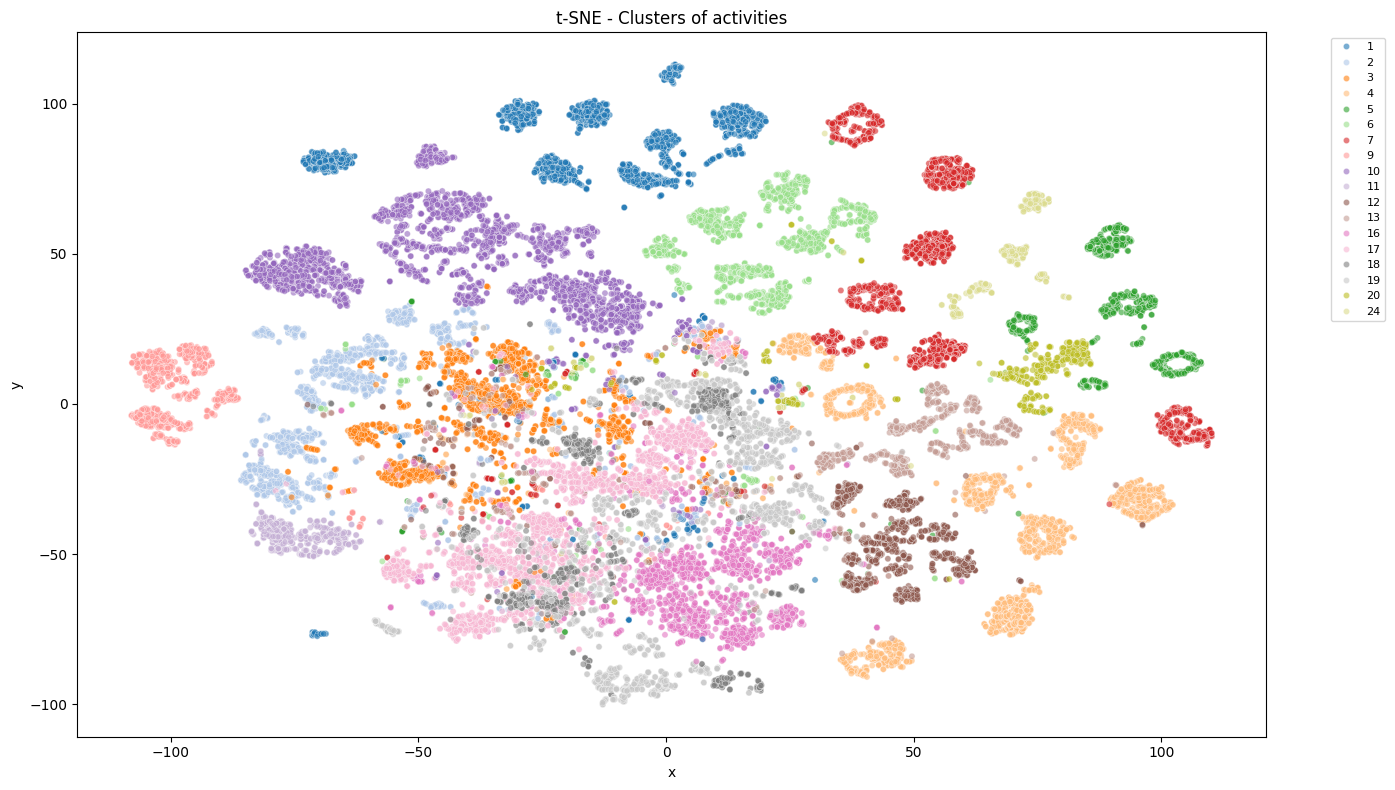

In [ ]:
# plt.figure(figsize=(14, 8))
# sns.scatterplot(
#     data=tsne_df,
#     x='x', y='y',
#     hue='activity',
#     palette='tab20',
#     alpha=0.6,
#     s=20
# )
# plt.title('t-SNE - Clusters of activities')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
# plt.tight_layout()
# plt.show()

In [ ]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_features': ['sqrt'],
    'max_depth':    [None, 10],
    'class_weight': ['balanced']
} # 18 combinations


def train_and_classify(X, y, groups):

    logo = LeaveOneGroupOut()
    n_groups = logo.get_n_splits(X, y, groups=groups)

    rf_predictions, true_labels = [], [],
    best_params = {'rf': []}


    for train_idx, test_idx in tqdm(logo.split(X, y, groups=groups), total=n_groups):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

        # RF
        gs_rf = GridSearchCV(
            RandomForestClassifier(n_jobs=-1),
            param_grid_rf,
            cv=inner_cv,
            scoring='f1_macro',
            n_jobs=-1
        )
        gs_rf.fit(X_train, y_train)
        best_params['rf'].append(gs_rf.best_params_)
        rf_predictions.extend(gs_rf.best_estimator_.predict(X_test))

        true_labels.extend(y_test)

    print("=== Random Forest ===")
    print(classification_report(true_labels, rf_predictions))

    return (
        classification_report(true_labels, rf_predictions,  output_dict=True),
        best_params
    )

In [40]:
groups = df_features['subject_id'].to_numpy()
colonnes_drop = X.columns[X.isna().any()].tolist()
X.drop(columns=colonnes_drop)

X_np   = X.to_numpy()
y_np   = y.to_numpy()


out = train_and_classify(X_np, y_np, groups)
print(len(out))

100%|██████████| 9/9 [13:17<00:00, 88.65s/it]

=== Random Forest ===
              precision    recall  f1-score   support

           1       0.45      0.97      0.62      1913
           2       0.72      0.71      0.72      1839
           3       0.50      0.61      0.55      1888
           4       0.91      0.93      0.92      2377
           5       0.87      0.79      0.83       973
           6       0.94      0.94      0.94      1634
           7       0.95      0.88      0.92      1870
           9       0.00      0.00      0.00       835
          10       0.87      0.55      0.68      3093
          11       0.00      0.00      0.00       544
          12       0.75      0.87      0.81      1158
          13       0.84      0.70      0.76      1037
          16       0.40      0.61      0.49      1741
          17       0.53      0.65      0.58      2373
          18       0.00      0.00      0.00       993
          19       0.29      0.24      0.26      1864
          20       0.55      0.40      0.46       466
     


/lustre09/project/6081099/haninih/HAR_models/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/lustre09/project/6081099/haninih/HAR_models/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/lustre09/project/6081099/haninih/HAR_models/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beh

In [41]:
print(out[1])

{'rf': [{'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}, {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}, {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 100}, {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}, {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}, {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}, {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}, {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}, {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}]}


In [ ]:


# ===== HYPERPARAMETER GRIDS FOR EACH CLASSIFIER =====

# Logistic Regression hyperparameters
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],           # Inverse regularization strength
    'solver': ['lbfgs'],                # Algorithm
    'max_iter': [5000],                 # Max iterations
    'class_weight': ['balanced']        # Handle class imbalance
}

# Support Vector Machine hyperparameters
param_grid_svm = {
    'C': [1, 10, 100],                 # Regularization parameter
    'gamma': [0.001, 0.01, 0.1],       # Kernel coefficient (RBF)
    'kernel': ['rbf'],                 # RBF kernel (non-linear)
    'class_weight': ['balanced']       # Handle class imbalance
}

# Random Forest hyperparameters
param_grid_rf = {
    'n_estimators': [200],             # Number of trees
    'max_features': ['sqrt'],          # Features per split
    'max_depth': [None],               # Tree depth (None = no limit)
    'class_weight': ['balanced']       # Handle class imbalance
}


def train_and_classify(X, y, groups):
    """
    Train classifiers using Leave-One-Group-Out cross-validation.
    
    Parameters:
    -----------
    X : np.ndarray
        Feature matrix (n_samples, n_features)
    y : np.ndarray
        Target labels (n_samples,)
    groups : np.ndarray
        Group labels for LOGO (subject IDs) (n_samples,)
        
    Returns:
    --------
    tuple
        (lr_report, svm_report, rf_report, best_params)
        where each *_report is a classification_report dict
    """
    
    # Initialize Leave-One-Group-Out cross-validation splitter
    logo = LeaveOneGroupOut()
    n_groups = logo.get_n_splits(X, y, groups=groups)

    # Initialize prediction storage
    lr_predictions, svm_predictions, rf_predictions, true_labels = [], [], [], []
    best_params = {'lr': [], 'svm': [], 'rf': []}

    print(f"\nStarting Leave-One-Group-Out (LOGO) Cross-Validation")
    print(f"Number of folds (subjects): {n_groups}\n")

    # Iterate through each fold
    for fold_num, (train_idx, test_idx) in enumerate(tqdm(logo.split(X, y, groups=groups), 
                                                           total=n_groups,
                                                           desc="LOGO Folds")):
        # Split data for this fold
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # ===== STANDARDIZATION (Important for LR & SVM) =====
        # Fit scaler on training set, apply to test set
        # (Prevents test set statistics from leaking into model)
        scaler = StandardScaler()
        X_train_sc = scaler.fit_transform(X_train)
        X_test_sc = scaler.transform(X_test)

        # ===== INNER CROSS-VALIDATION FOR HYPERPARAMETER TUNING =====
        # Use stratified 3-fold CV within training set
        inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

        # ===== LOGISTIC REGRESSION =====
        print(f"  Fold {fold_num + 1}/{n_groups}: Training LR, SVM, RF...")
        
        gs_lr = GridSearchCV(
            LogisticRegression(max_iter=5000),
            param_grid_lr,
            cv=inner_cv,
            scoring='f1_macro',  # Weighted F1-score handles imbalance
            n_jobs=-1
        )
        gs_lr.fit(X_train_sc, y_train)
        best_params['lr'].append(gs_lr.best_params_)
        lr_predictions.extend(gs_lr.best_estimator_.predict(X_test_sc))

        # ===== SUPPORT VECTOR MACHINE =====
        gs_svm = GridSearchCV(
            SVC(),
            param_grid_svm,
            cv=inner_cv,
            scoring='f1_macro',
            n_jobs=-1
        )
        gs_svm.fit(X_train_sc, y_train)
        best_params['svm'].append(gs_svm.best_params_)
        svm_predictions.extend(gs_svm.best_estimator_.predict(X_test_sc))

        # ===== RANDOM FOREST =====
        gs_rf = GridSearchCV(
            RandomForestClassifier(n_jobs=-1),
            param_grid_rf,
            cv=inner_cv,
            scoring='f1_macro',
            n_jobs=-1
        )
        gs_rf.fit(X_train, y_train)  # RF doesn't require scaling
        best_params['rf'].append(gs_rf.best_params_)
        rf_predictions.extend(gs_rf.best_estimator_.predict(X_test))

        # Collect true labels for this fold
        true_labels.extend(y_test)

    # ===== GENERATE CLASSIFICATION REPORTS =====
    print("\n" + "="*70)
    print("CLASSIFICATION RESULTS (LOGO Cross-Validation)")
    print("="*70)
    
    print("\n>>> LOGISTIC REGRESSION")
    print(classification_report(true_labels, lr_predictions, 
                              target_names=[activities[a] for a in activities]))

    print("\n>>> SUPPORT VECTOR MACHINE")
    print(classification_report(true_labels, svm_predictions,
                              target_names=[activities[a] for a in activities]))

    print("\n>>> RANDOM FOREST")
    print(classification_report(true_labels, rf_predictions,
                              target_names=[activities[a] for a in activities]))

    return (
        classification_report(true_labels, lr_predictions, output_dict=True),
        classification_report(true_labels, svm_predictions, output_dict=True),
        classification_report(true_labels, rf_predictions, output_dict=True),
        best_params
    )

### 7.2: Train Multiple Classifiers with Subject-Independent Evaluation

**Cross-Validation Strategy: Leave-One-Group-Out (LOGO)**
- **Group**: Each subject (9 subjects in PAMAP2)
- **Procedure**: Train on data from 8 subjects, test on 1 left-out subject
- **Repetition**: 9 folds (one per subject)
- **Benefit**: Ensures model generalizes to new, unseen subjects (real-world deployment scenario)

**Classifiers Evaluated**:
1. **Logistic Regression (LR)** - Fast, interpretable, baseline
2. **Support Vector Machine (SVM)** - Powerful, good for smaller datasets
3. **Random Forest (RF)** - Robust, captures non-linear patterns

Each classifier uses hyperparameter tuning (GridSearchCV) on the training set.

In [7]:
groups = df_features['subject_id'].to_numpy()
colonnes_drop = X.columns[X.isna().any()].tolist()
X.drop(columns=colonnes_drop)

X_np   = X.to_numpy()
y_np   = y.to_numpy()


out = train_and_classify(X_np, y_np, groups)
print(len(out))

100%|██████████| 9/9 [2:31:50<00:00, 1012.26s/it]  

=== LR ===
              precision    recall  f1-score   support

           1       0.66      0.95      0.78      1913
           2       0.66      0.71      0.69      1839
           3       0.46      0.51      0.48      1888
           4       0.92      0.88      0.90      2377
           5       0.76      0.83      0.80       973
           6       0.75      0.94      0.83      1634
           7       0.96      0.88      0.92      1870
           9       0.00      0.00      0.00       835
          10       0.70      0.26      0.38      3093
          11       0.00      0.00      0.00       544
          12       0.62      0.81      0.70      1158
          13       0.57      0.76      0.65      1037
          16       0.49      0.88      0.63      1741
          17       0.52      0.72      0.61      2373
          18       0.16      0.07      0.10       993
          19       0.46      0.36      0.41      1864
          20       0.54      0.48      0.51       466
          24    


/lustre09/project/6081099/haninih/HAR_models/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/lustre09/project/6081099/haninih/HAR_models/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/lustre09/project/6081099/haninih/HAR_models/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beh

### 7.3: Execute Training & Evaluation

Run the LOGO cross-validation pipeline. This will train and evaluate all three classifiers.

In [43]:
models = {'SVM' : out[1],
          'LR' : out[0],
          'RF' : out[2]}

data_for_plot = []
for model_name, rep in models.items():
    print(f"{model_name} Accuracy: {rep['accuracy']:.4f}")
    
    for act in activities:
        act_name = activities[act] 
        f1 = rep[str(act)]['f1-score']
        data_for_plot.append({
            'Model': model_name,
            'Activity': act_name,
            'F1-Score': f1
        })

print('\n')

df_scores = pd.DataFrame(data_for_plot)

df_pivot = df_scores.pivot(index='Activity', columns='Model', values='F1-Score')

plt.figure(figsize=(10, 6))
df_pivot.plot(kind='bar', ax=plt.gca(), width=0.8)

plt.title("Comparaison F1-Scores", fontsize=14, fontweight='bold')
plt.xlabel("Activities", fontsize=12)
plt.ylabel("F1-Score", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Models")

plt.tight_layout()
plt.show()

IndexError: tuple index out of range

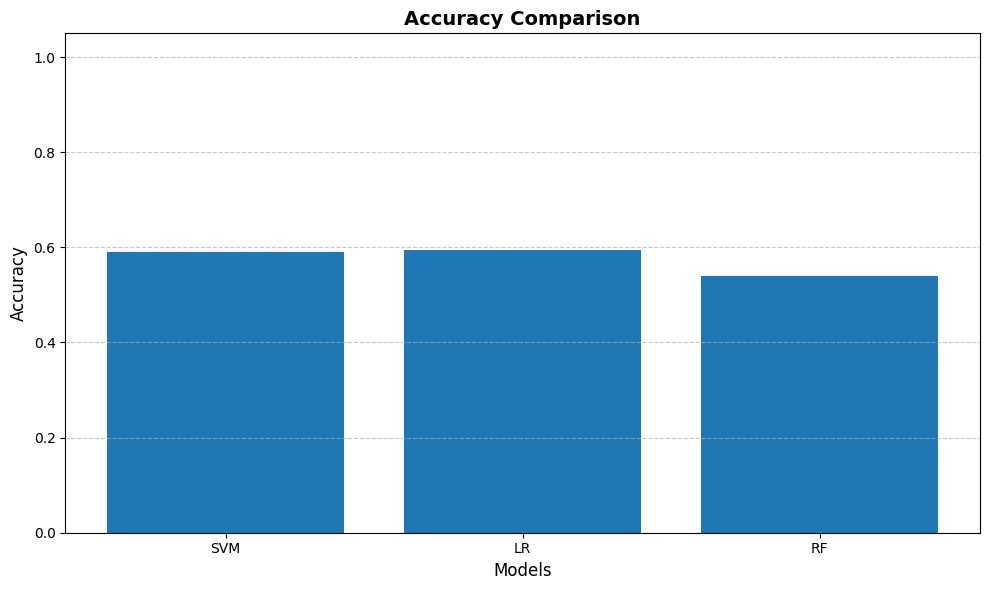

In [ ]:
data_for_plot = []
for model_name, rep in models.items():
    acc = rep['accuracy']
    data_for_plot.append({
        'Model': model_name,
        'Accuracy': acc
        })

print('\n')

df_scores = pd.DataFrame(data_for_plot)

plt.figure(figsize=(10, 6))
plt.bar(df_scores['Model'], df_scores['Accuracy'])

plt.title("Accuracy Comparison", fontsize=14, fontweight='bold')
plt.xlabel("Models", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()